In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from adjustText import adjust_text
import seaborn as sns
from matplotlib import rcParams
import pickle


# --- Setup Matplotlib for consistent font rendering ---
rcParams['pdf.fonttype'] = 42
rcParams['ps.fonttype'] = 42
rcParams['font.family'] = 'DejaVu Sans'
%matplotlib inline

In [2]:
deg_keycluster = pd.read_csv("/home/nilabjab/cancer_dependency_project_nilabja/cancer_dependency_project/Approach3_Latent_factor/git_repo/Data/depMap_keyCluster_deg_optuna.csv")

In [3]:
print("--- Step 1: Loading and processing DEG results ---")

df = deg_keycluster

# Rename gene column properly
df = df.rename(columns={"Unnamed: 0": "gene"})

# Drop rows with missing critical values (safety)
df = df.dropna(subset=["logFC", "P.Value", "adj.P.Val"])

# Compute -log10(p) safely (handles ultra-small p-values)
df["-log10p"] = -np.log10(df["P.Value"] + np.finfo(float).tiny)

# Define thresholds
padj_threshold = 0.05
logfc_threshold = 1.0

# Assign significance categories
conditions = [
    (df["logFC"] > logfc_threshold) & (df["adj.P.Val"] < padj_threshold),
    (df["logFC"] < -logfc_threshold) & (df["adj.P.Val"] < padj_threshold)
]
choices = ["Up-regulated", "Down-regulated"]

df["significance"] = np.select(
    conditions,
    choices,
    default="Not Significant"
)

print("Data processing complete.")


--- Step 1: Loading and processing DEG results ---
Data processing complete.


In [4]:
counts = df['significance'].value_counts()

upregulated = counts.get('Up-regulated', 0)
downregulated = counts.get('Down-regulated', 0)

print(f"Upregulated genes: {upregulated}")
print(f"Downregulated genes: {downregulated}")
print(f"Total DE genes: {upregulated + downregulated}")


Upregulated genes: 221
Downregulated genes: 717
Total DE genes: 938


In [5]:
df["abs_logFC"] = df["logFC"].abs()

genes_to_label = (
    df[df["significance"] != "Not Significant"]
    .sort_values(by=["adj.P.Val", "abs_logFC"], ascending=[True, False])
    .head(30)
)


In [6]:
dep_path = "/home/nilabjab/cancer_dependency_project_nilabja/cancer_dependency_project/Approach3_Latent_factor/Fresh_FORGE/Data/Dep.csv"
ic50_path = "/home/nilabjab/cancer_dependency_project_nilabja/cancer_dependency_project/Approach3_Latent_factor/Fresh_FORGE/Data/Creammist_common_ic50.csv"
dep_data = pd.read_csv(dep_path, header = 0, index_col = 0)
ic50_data = pd.read_csv(ic50_path, header = 0, index_col = 0)
ic50_data = ic50_data.T

In [7]:
joint_model_path = '/home/sreeramp/cancer_dependency_project/nilabja/Approach3_Latent_factor/git_repo/Models/optuna_models/ERLOTINIB_EGFR_forgeModel_optuna100.pkl'

In [8]:
from forge_class_instance3 import FORGE as forge_optuna
joint_model = forge_optuna.load_forge(path = joint_model_path)

In [9]:
exp_data = pd.read_csv(joint_model.exp_path, header = 0, index_col = 0)

In [10]:
with open(joint_model_path, 'rb') as f:
        joint_model_i = pickle.load(f)

In [11]:
# === Gene Influence Calculation with L2 scaling ===
def calculate_scaled_gene_influence(W, h_D, h_I, gene_names):
    # L2 normalization
    h_D_norm = h_D / np.linalg.norm(h_D)
    h_I_norm = h_I / np.linalg.norm(h_I)

    # Influence calculation
    ic50_effect = -W @ h_I_norm
    dependency_effect = W @ h_D_norm
    total_influence = dependency_effect + ic50_effect  # or W @ (h_D_norm - h_I_norm)

    influence_df = pd.DataFrame({
        "Gene": gene_names,
        "IC50Effect": ic50_effect.ravel(),
        "DependencyEffect": dependency_effect.ravel(),
        "TotalInfluence": total_influence.ravel()
    }).set_index("Gene")

    return influence_df

# === Call the function ===
influence_df = calculate_scaled_gene_influence(joint_model_i.W, joint_model_i.hD, joint_model_i.hI, joint_model_i.hcg_list)


In [12]:
influence_df.head()

,IC50Effect,DependencyEffect,TotalInfluence
Gene,,,
MYBL1,-0.526136,-0.059584,-0.585720
UBL7-DT,0.193163,-0.117613,0.075550
AK5,-0.765622,0.415748,-0.349873
REPS1,0.749249,-0.035611,0.713637
GGN,-0.825723,-0.467909,-1.293633


--- Step 3: Generating the volcano plot ---


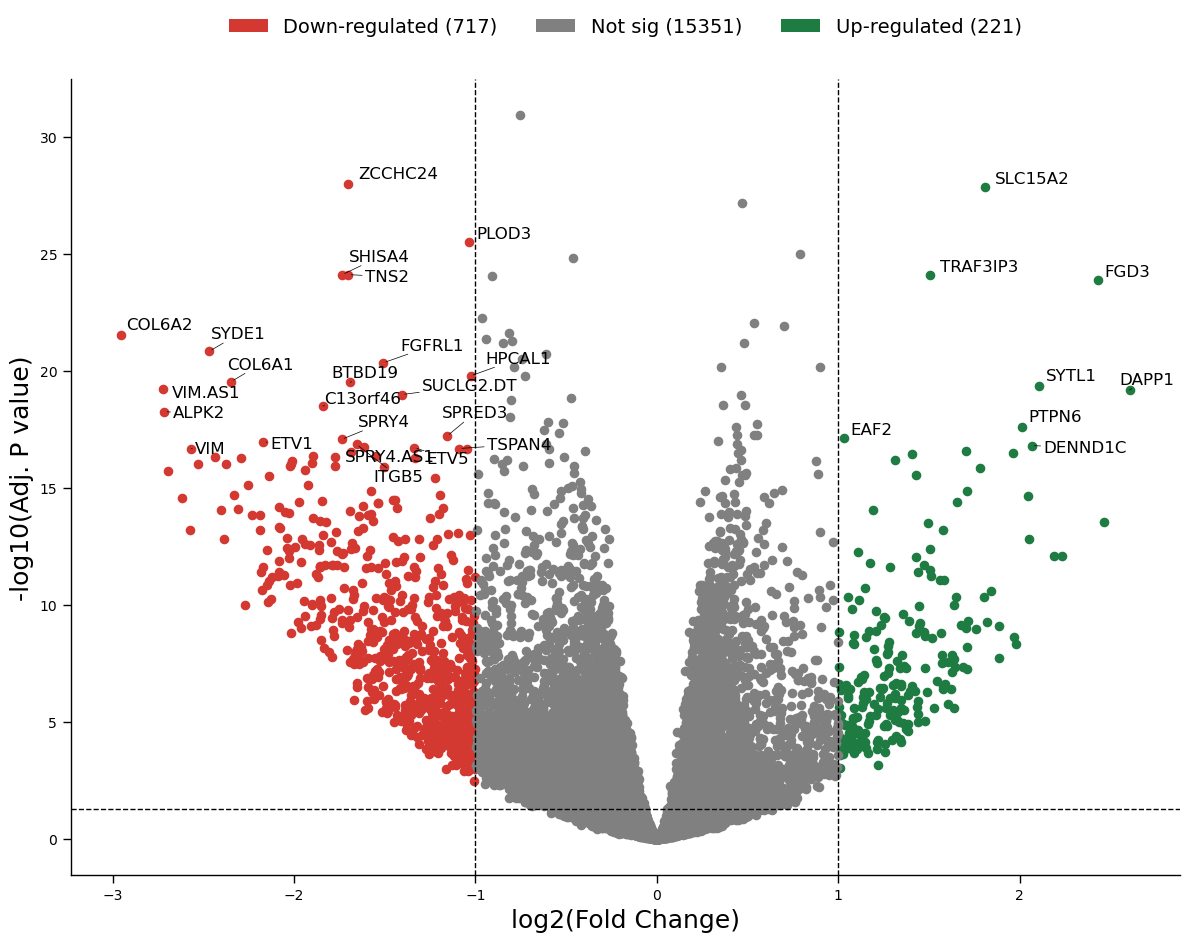

In [13]:
# --- 4. Plotting ---
print("--- Step 3: Generating the volcano plot ---")


# Define colors and create dynamic legend labels
#color_map = {'Up-regulated': "#f56e30", 'Down-regulated': '#00bfc4', 'Not Significant': 'grey'}
color_map = {'Up-regulated': "#1e7c43", 'Down-regulated': '#d33831', 'Not Significant': 'grey'}
counts = df['significance'].value_counts()
legend_labels = {
    'Down-regulated': f"Down-regulated ({counts.get('Down-regulated', 0)})",
    'Not Significant': f"Not sig ({counts.get('Not Significant', 0)})",
    'Up-regulated': f"Up-regulated ({counts.get('Up-regulated', 0)})"
}

fig, ax = plt.subplots(figsize=(12, 10))  # Width=8 inches, Height=6 inches


# Plot points for each group (ALL rasterized)
for sig_type, color in color_map.items():
    subset = df[df['significance'] == sig_type]
    ax.scatter(subset['logFC'], subset['-log10p'], color=color, alpha=1, s=35, rasterized=True)


# --- 5. Add Annotations and Customize Aesthetics ---
# Add gene labels using adjustText to prevent overlap
texts = [ax.text(row['logFC'], row['-log10p'], row['gene'], color='black', fontsize=12)
         for i, row in genes_to_label.iterrows()]
adjust_text(texts, ax=ax, arrowprops=dict(arrowstyle="-", color='black', lw=0.5),
            force_text=(0.1, 0.5))

# Add threshold lines
ax.axvline(x=-logfc_threshold, linestyle='--', color='black', lw=1)
ax.axvline(x=logfc_threshold, linestyle='--', color='black', lw=1)
ax.axhline(y=-np.log10(padj_threshold), linestyle='--', color='black', lw=1)

# Set labels
ax.set_xlabel('log2(Fold Change)', fontsize=18)
ax.set_ylabel('-log10(Adj. P value)', fontsize=18)


# Create a custom legend
#legend_elements = [Patch(facecolor=c, label=l) for c, l in zip(color_map.values(), legend_labels.values())]

# Make sure this order matches the plotting order

# Explicitly define the order
ordered_labels = ['Down-regulated', 'Not Significant', 'Up-regulated']

# Build legend elements correctly
legend_elements = [
    Patch(facecolor=color_map[label], label=legend_labels[label])
    for label in ordered_labels
]

#legend_elements = [Patch(facecolor=color_map[key], label=f"{legend_labels[key]} ({counts[key]})")
#                   for key in color_map]

ax.legend(handles=legend_elements, loc='upper center', bbox_to_anchor=(0.5, 1.1),
          ncol=3, frameon=False, fontsize=14)

# --- FIX #3 (PLOTTING): Remove manual ylim setting to prevent label clipping ---
# Let matplotlib and adjust_text automatically set the limits to ensure all labels are visible.
# plt.ylim(0, df['-log10p'].max() * 1.1) <-- REMOVED THIS LINE

# Clean up the plot aesthetics
ax.grid(False)
for spine in ['bottom', 'left']:
    ax.spines[spine].set_linewidth(1)
for spine in ['top', 'right']:
    ax.spines[spine].set_visible(False)
ax.tick_params(axis='both', which='both', width=1,length=6, direction='out')

# --- 6. Save and Show the Plot ---
plt.tight_layout(rect=[0, 0, 1, 0.95])
#plt.savefig("/home/nilabjab/cancer_dependency_project_nilabja/cancer_dependency_project/Approach3_Latent_factor/git_repo/Figs/Fig5/Daporinad_volcano_plot.pdf", dpi=600, bbox_inches='tight')

#print(f"\nDebugged volcano plot saved to: {output_plot_path}")
plt.show()

In [16]:
subset

,gene,logFC,AveExpr,t,P.Value,adj.P.Val,B,-log10p,significance,abs_logFC,TotalInfluence,Influence_Z
6,TMEM115,-0.461559,4.972098,-10.877127,1.565727e-25,3.643446e-22,47.102871,24.805284,Not Significant,0.461559,-0.013978,NaN
65,TSPAN4,-1.089662,4.977018,-8.719709,2.092411e-17,5.068378e-15,28.844762,16.679353,Down-regulated,1.089662,0.019770,NaN
7768,PERP,-0.525222,6.506754,-2.305931,2.141179e-02,4.489337e-02,-4.123799,1.669347,Not Significant,0.525222,0.028381,NaN
15584,TINAGL1,-0.059629,3.744629,-0.185632,8.527882e-01,8.913100e-01,-6.722520,0.069159,Not Significant,0.059629,-0.059308,NaN
2286,PRSS8,1.528515,1.153776,4.746001,2.526104e-06,1.799200e-05,4.203220,5.597549,Up-regulated,1.528515,0.077419,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...
3693,FGFBP1,1.260288,0.233265,3.939067,9.016535e-05,3.975916e-04,0.836749,4.044960,Up-regulated,1.260288,3.023650,NaN
3130,TAOK2,-0.164579,6.143124,-4.240029,2.541228e-05,1.322071e-04,2.023063,4.594956,Not Significant,0.164579,-3.040438,NaN
4808,TACSTD2,1.221930,2.507135,3.405265,6.995089e-04,2.369370e-03,-1.061357,3.155207,Up-regulated,1.221930,-3.133292,NaN
15948,EPS8L2,0.020170,4.879509,0.084793,9.324506e-01,9.523285e-01,-6.735987,0.030374,Not Significant,0.020170,3.313723,NaN


In [19]:
df_plot.to_csv("/home/nilabjab/cancer_dependency_project_nilabja/cancer_dependency_project/Approach3_Latent_factor/git_repo/revision_final/Suppl_data/highly_susceptible_cluster.csv", index=False)

--- Step 4: Merging Influence Data and Plotting ---
Genes with influence data: 0


/tmp/ipykernel_544916/3443333106.py:49: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap('PuOr_r')


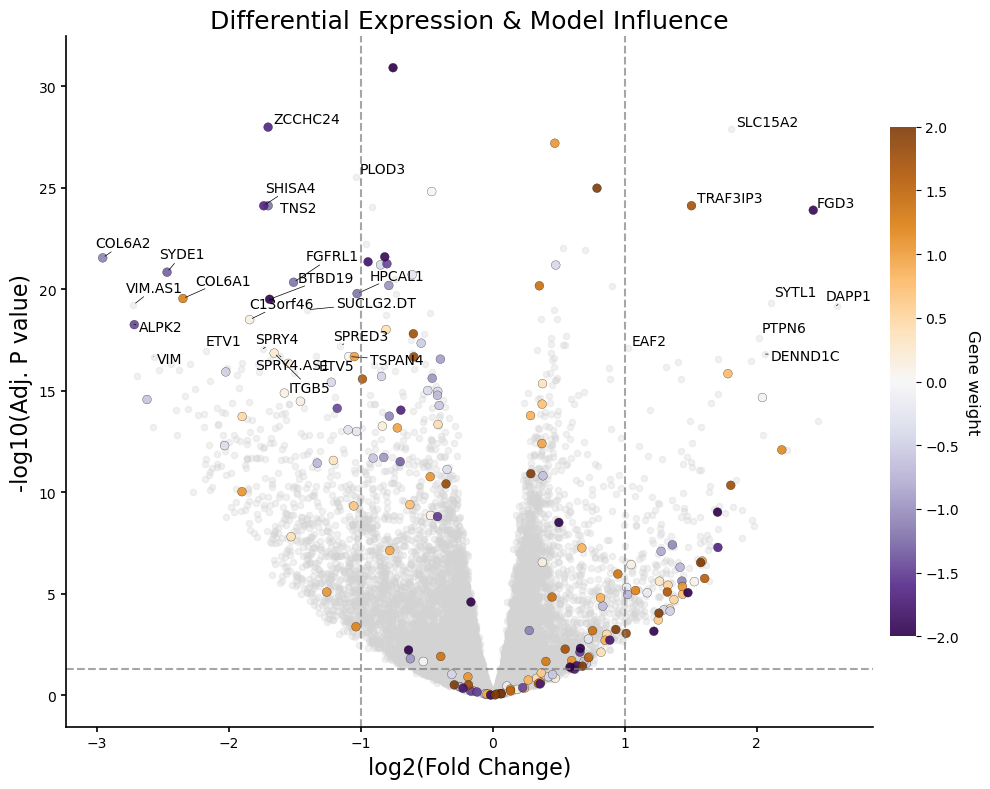

In [15]:
print("--- Step 4: Merging Influence Data and Plotting ---")

# 1. Merge TotalInfluence into the DEG dataframe
# We map the values based on the 'gene' column
df['TotalInfluence'] = df['gene'].map(influence_df['TotalInfluence'])

# 2. Z-scale the Influence values
# This normalizes the weights for the colorbar (Standard Score)
# Genes not in influence_df will be NaN and excluded from the coloring
inf_values = df['TotalInfluence'].dropna()
df['Influence_Z'] = np.nan # Initialize
#df.loc[inf_values.index, 'Influence_Z'] = (inf_values - inf_values.mean()) / inf_values.std()

print(f"Genes with influence data: {df['Influence_Z'].notna().sum()}")

# 3. Sort for plotting order
# We sort by absolute influence so the most colored points are plotted on top
df_plot = df.sort_values(by='TotalInfluence', key=abs, na_position='first')

# %%
# --- Plotting ---
fig, ax = plt.subplots(figsize=(10, 8))

# Define Thresholds from your previous logic
padj_threshold = 0.05
logfc_threshold = 1.0

# A. Plot Background/Non-Influence Genes (Grey)
# These are genes that have DEG stats but NO influence score in the model
mask_no_inf = df_plot['TotalInfluence'].isna()
ax.scatter(
    df_plot.loc[mask_no_inf, 'logFC'], 
    df_plot.loc[mask_no_inf, '-log10p'], 
    c='lightgrey', 
    s=20, 
    alpha=0.3, 
    label='No Influence Data',
    rasterized=True
)

# B. Plot Genes with Influence Scores (Colored by TotalInfluence)
mask_has_inf = df_plot['TotalInfluence'].notna()
subset = df_plot.loc[mask_has_inf]

# Use a diverging colormap (Purple to Orange is common, or Red-Blue)
# 'PuOr_r' creates a Purple (neg) <-> Orange (pos) map. 
# 'RdBu_r' creates Blue (pos) <-> Red (neg). 
# Based on the earlier image style (Purple to Blue-ish), 'PuOr_r' or 'coolwarm' works well.
cmap = plt.cm.get_cmap('PuOr_r') 

sc = ax.scatter(
    subset['logFC'], 
    subset['-log10p'], 
    c=subset['TotalInfluence'], 
    cmap=cmap, 
    s=40, 
    alpha=0.9, 
    edgecolor='black', 
    linewidth=0.2,
    vmin=-2, vmax=2, # Clip visualization at +/- 2 Std Devs for contrast
    rasterized=True
)

# --- Add Colorbar ---
cbar = plt.colorbar(sc, ax=ax, fraction=0.03, pad=0.02)
cbar.set_label('Gene weight', rotation=270, labelpad=15, fontsize=12)
cbar.outline.set_visible(False) # Clean look


# --- Add Threshold Lines ---
ax.axvline(x=-logfc_threshold, linestyle='--', color='grey', lw=1.5, alpha=0.7)
ax.axvline(x=logfc_threshold, linestyle='--', color='grey', lw=1.5, alpha=0.7)
ax.axhline(y=-np.log10(padj_threshold), linestyle='--', color='grey', lw=1.5, alpha=0.7)

# --- Add Annotations (Top Genes) ---
# Using your previous 'genes_to_label' logic
texts = []
for i, row in genes_to_label.iterrows():
    # Only label if it's within the axis limits (optional check)
    texts.append(
        ax.text(row['logFC'], row['-log10p'], row['gene'], color='black', fontsize=10)
    )

adjust_text(
    texts, 
    ax=ax, 
    arrowprops=dict(arrowstyle="-", color='black', lw=0.5),
    force_text=(0.2, 0.5) # Adjust these force parameters if labels fly too far
)

# --- Cosmetics ---
ax.set_xlabel('log2(Fold Change)', fontsize=16)
ax.set_ylabel('-log10(Adj. P value)', fontsize=16)
ax.set_title('Differential Expression & Model Influence', fontsize=18)

# Clean spines
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['bottom'].set_linewidth(1.2)
ax.spines['left'].set_linewidth(1.2)
ax.tick_params(width=1.2)

plt.tight_layout()
#plt.savefig("/home/nilabjab/cancer_dependency_project_nilabja/cancer_dependency_project/Approach3_Latent_factor/git_repo/Figs/Suppl_figs/Volcano_Influence_Colored.pdf", dpi=300, bbox_inches='tight')
plt.show()